In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
products = pd.read_csv("products.csv")
sellers = pd.read_csv("sellers.csv")
geolocation = pd.read_csv("geolocation.csv")

print("All 7 datasets loaded successfully!")

All 7 datasets loaded successfully!


In [7]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

Customers
Rows: 99441
Columns: 5
Orders
Rows: 99441
Columns: 8
Order Items
Rows: 112650
Columns: 7
Payments
Rows: 103886
Columns: 5
Products
Rows: 32951
Columns: 9
Sellers
Rows: 3095
Columns: 4
Geolocation
Rows: 1000163
Columns: 5


In [8]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

In [9]:
orders["year"] = orders["order_purchase_timestamp"].dt.year
orders["month"] = orders["order_purchase_timestamp"].dt.month
orders["month_name"] = orders["order_purchase_timestamp"].dt.month_name()
orders["quarter"] = orders["order_purchase_timestamp"].dt.quarter

In [10]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation
}

for name, df in datasets.items():

    print("=" * 60)
    print(name)

    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

    print("\nData types:")
    print(df.dtypes)

Customers
Rows: 99441
Columns: 5

Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate rows: 0

Data types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
Orders
Rows: 99441
Columns: 12

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
year                                0
month                               0
month_name                          0
quarter                             0
dtype: int64

Duplicate rows: 0

Data types:
order_id         

In [13]:
for df in [customers, orders, order_items, payments, products, sellers, geolocation]:
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

In [14]:
products["product_category"] = (
    products["product_category"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

In [15]:
customers["customer_city"] = (
    customers["customer_city"]
    .astype(str)
    .str.strip()
    .str.lower()
)

customers["customer_state"] = (
    customers["customer_state"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [16]:
sellers["seller_city"] = (
    sellers["seller_city"]
    .astype(str)
    .str.strip()
    .str.lower()
)

sellers["seller_state"] = (
    sellers["seller_state"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [17]:
analysis_df = (
    orders
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
    .merge(
        order_items,
        on="order_id",
        how="left"
    )
    .merge(
        products,
        on="product_id",
        how="left"
    )
    .merge(
        sellers,
        on="seller_id",
        how="left"
    )
)

In [18]:
analysis_df["product_category"] = (
    analysis_df["product_category"]
    .fillna("Unknown")
)

In [19]:
analysis_df["revenue"] = analysis_df["price"]

analysis_df["order_item_value"] = (
    analysis_df["price"] +
    analysis_df["freight_value"]
)

# ***BASIC LEVEL***

# **BASIC 1 — Unique Cities Where Customers Are Located**

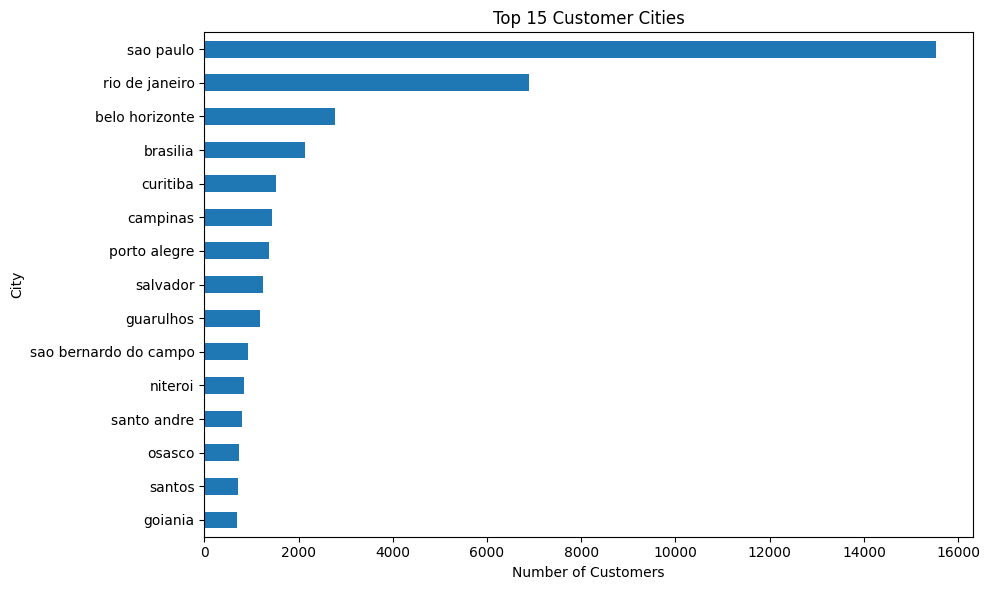

In [20]:
city_counts = (
    customers.groupby("customer_city")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
city_counts.sort_values().plot(kind="barh")
plt.title("Top 15 Customer Cities")
plt.xlabel("Number of Customers")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# **Number of Orders Placed in 2017**

In [21]:
orders_2017 = orders[
    orders["order_purchase_timestamp"].dt.year == 2017
]

print("Orders in 2017:", len(orders_2017))

Orders in 2017: 45101


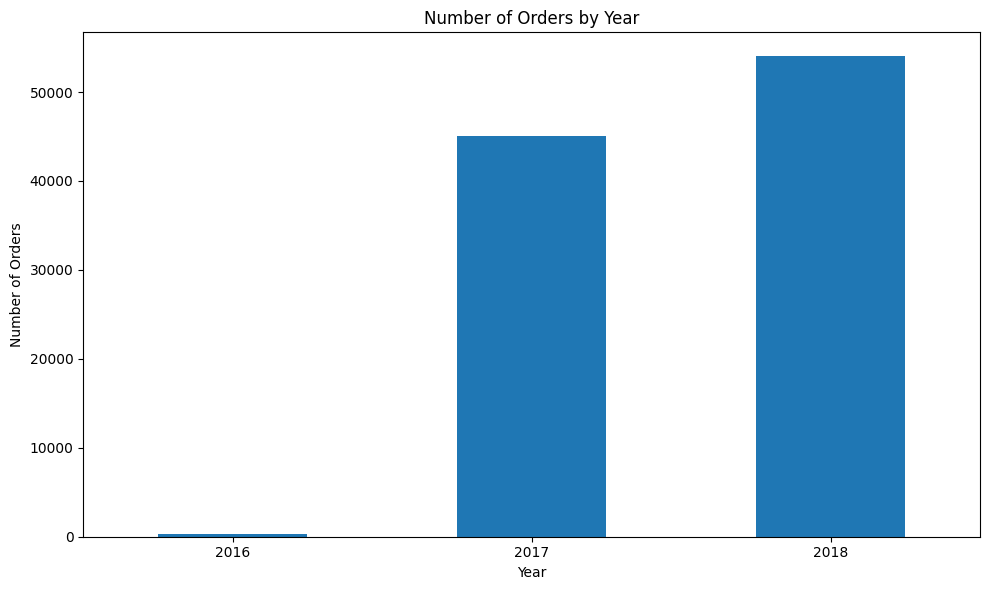

In [49]:
orders_by_year = (
    orders["order_purchase_timestamp"]
    .dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

orders_by_year.plot(kind="bar")

plt.title("Number of Orders by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **BASIC 3 — Total sales per category**

In [23]:
category_sales = (
    order_items
    .merge(
        products[["product_id", "product_category"]],
        on="product_id",
        how="left"
    )
)

category_sales["product_category"] = (
    category_sales["product_category"]
    .fillna("Unknown")
)

category_sales = (
    category_sales
    .groupby("product_category")["price"]
    .sum()
    .sort_values(ascending=False)
)

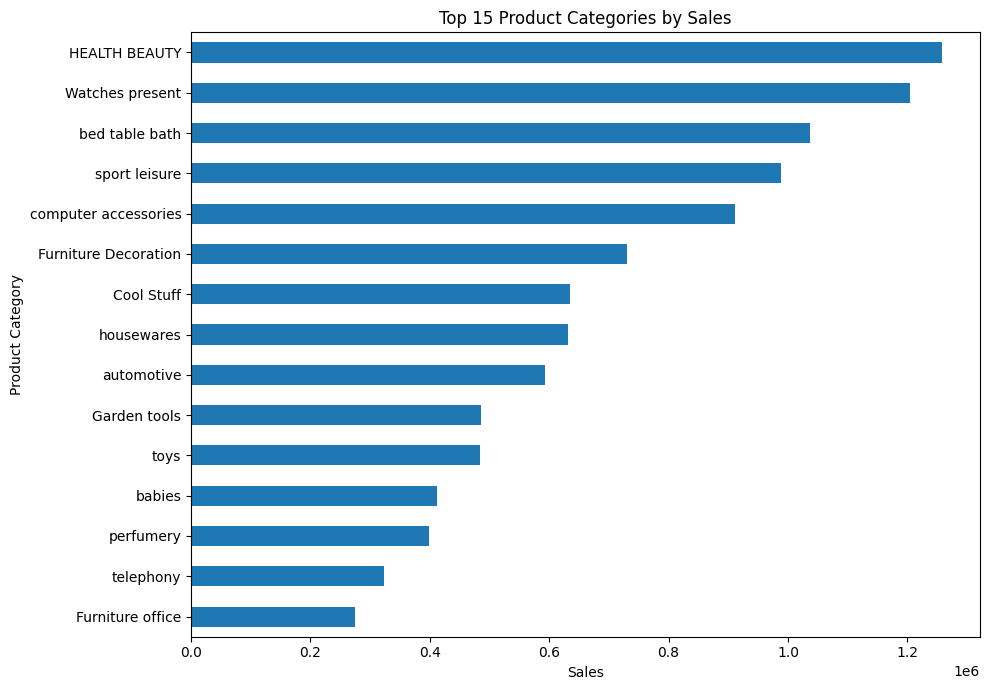

In [24]:
top_categories = category_sales.head(15)

plt.figure(figsize=(10,7))
top_categories.sort_values().plot(kind="barh")
plt.title("Top 15 Product Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

# **BASIC 4 — Percentage of orders paid in installments**

In [25]:
order_payment = (
    payments.groupby("order_id")["payment_installments"]
    .max()
)

installment_percentage = (
    (order_payment > 1).mean() * 100
)

print(f"Installment payment percentage: {installment_percentage:.2f}%")

Installment payment percentage: 51.46%


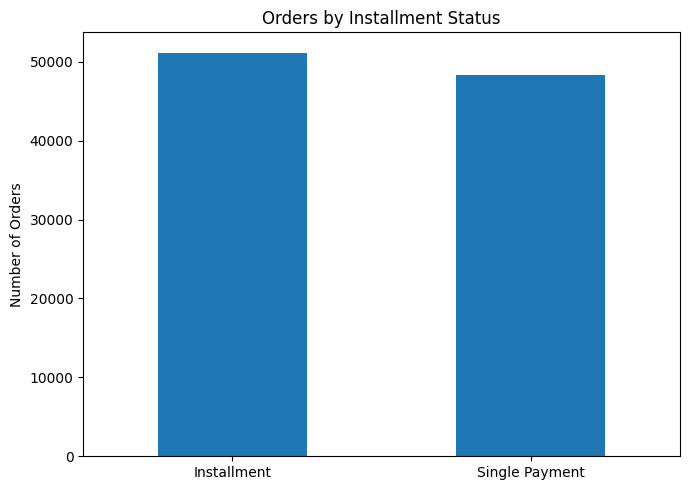

In [26]:
payment_status = pd.Series({
    "Installment": (order_payment > 1).sum(),
    "Single Payment": (order_payment <= 1).sum()
})

plt.figure(figsize=(7,5))
payment_status.plot(kind="bar")
plt.title("Orders by Installment Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **BASIC 5 — Customers from each state**

In [27]:
state_customers = (
    customers.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

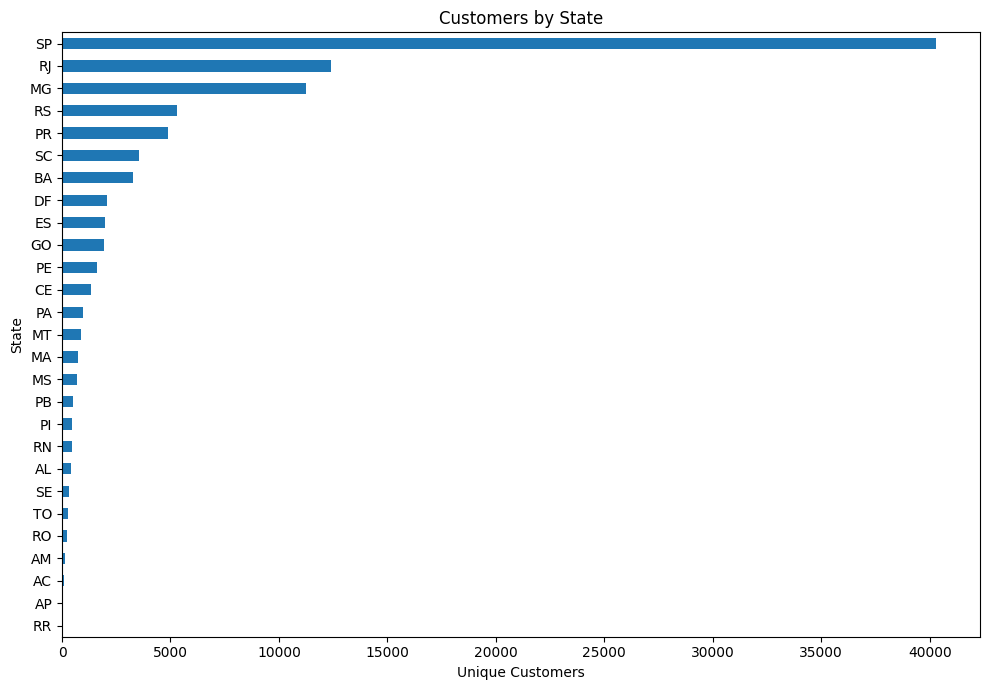

In [28]:
plt.figure(figsize=(10,7))
state_customers.sort_values().plot(kind="barh")
plt.title("Customers by State")
plt.xlabel("Unique Customers")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# ***INTERMEDIATE ANALYSIS***

# **Intermediate 1 — Orders per month in 2018**

In [29]:
orders_2018 = orders[
    orders["order_purchase_timestamp"].dt.year == 2018
].copy()

monthly_orders_2018 = (
    orders_2018
    .groupby(orders_2018["order_purchase_timestamp"].dt.month)
    .size()
)

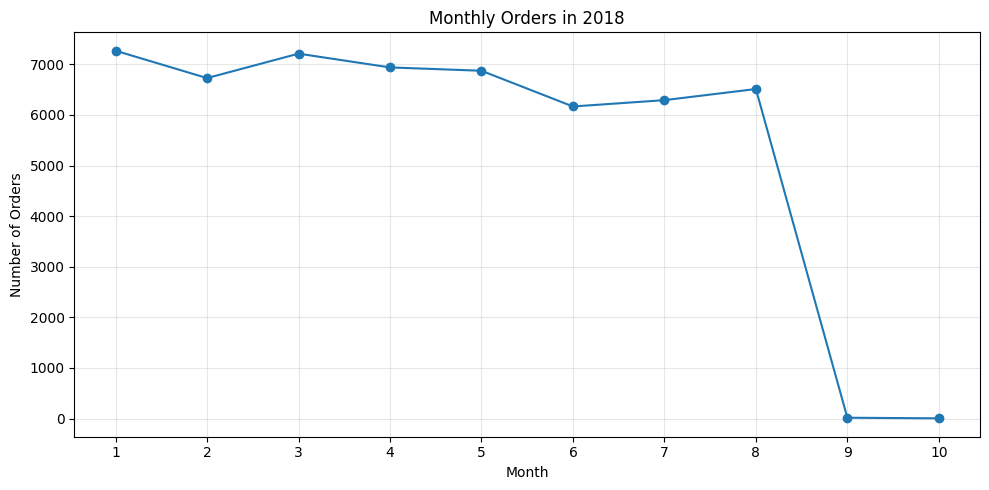

In [30]:
plt.figure(figsize=(10,5))
monthly_orders_2018.plot(kind="line", marker="o")
plt.title("Monthly Orders in 2018")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Intermediate 2 — Average products per order by customer city**

In [31]:
order_product_count = (
    order_items.groupby("order_id")
    .size()
    .reset_index(name="products_in_order")
)

order_city = (
    orders[["order_id", "customer_id"]]
    .merge(order_product_count, on="order_id")
    .merge(
        customers[["customer_id", "customer_city"]],
        on="customer_id"
    )
)

avg_products_city = (
    order_city.groupby("customer_city")["products_in_order"]
    .mean()
    .sort_values(ascending=False)
)

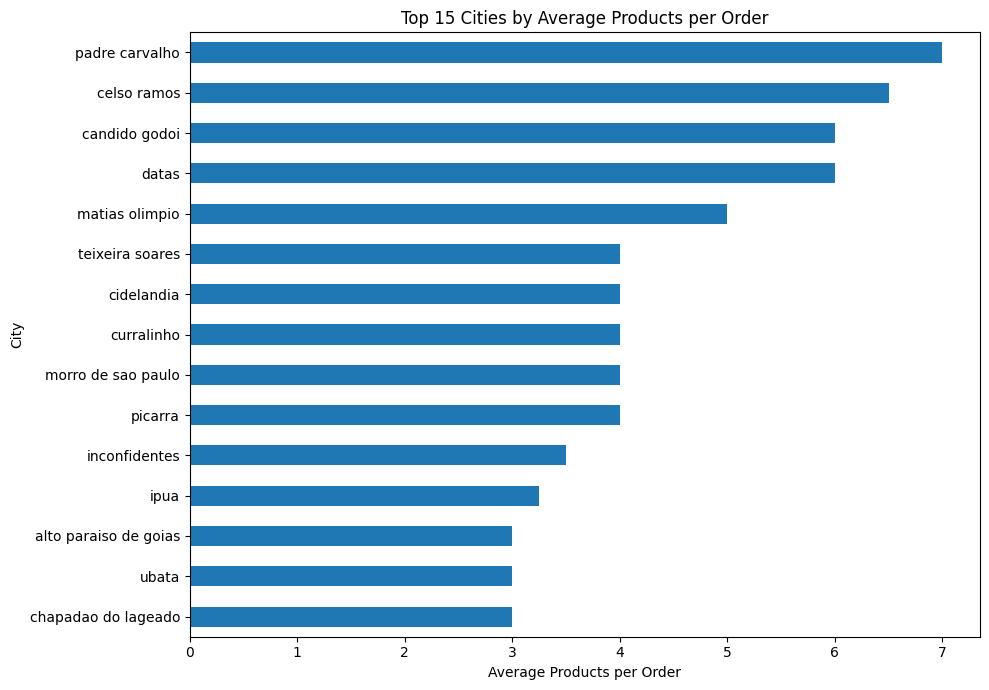

In [32]:
plt.figure(figsize=(10,7))
avg_products_city.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Cities by Average Products per Order")
plt.xlabel("Average Products per Order")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# **Intermediate 3 — Revenue percentage by category**

In [38]:
category_sales = order_items.merge(
    products[["product_id", "product_category"]],
    on="product_id",
    how="left"
)

category_sales["product_category"] = (
    category_sales["product_category"]
    .fillna("Unknown")
)

category_revenue = (
    category_sales.groupby("product_category")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_percentage = (
    category_revenue /
    category_revenue.sum() * 100
)

print(category_percentage)

product_category
HEALTH BEAUTY                  9.260700
Watches present                8.865783
bed table bath                 7.629605
sport leisure                  7.269533
computer accessories           6.709669
                                 ...   
flowers                        0.008167
House Comfort 2                0.005594
cds music dvds                 0.005371
Fashion Children's Clothing    0.004193
insurance and services         0.002084
Name: price, Length: 74, dtype: float64


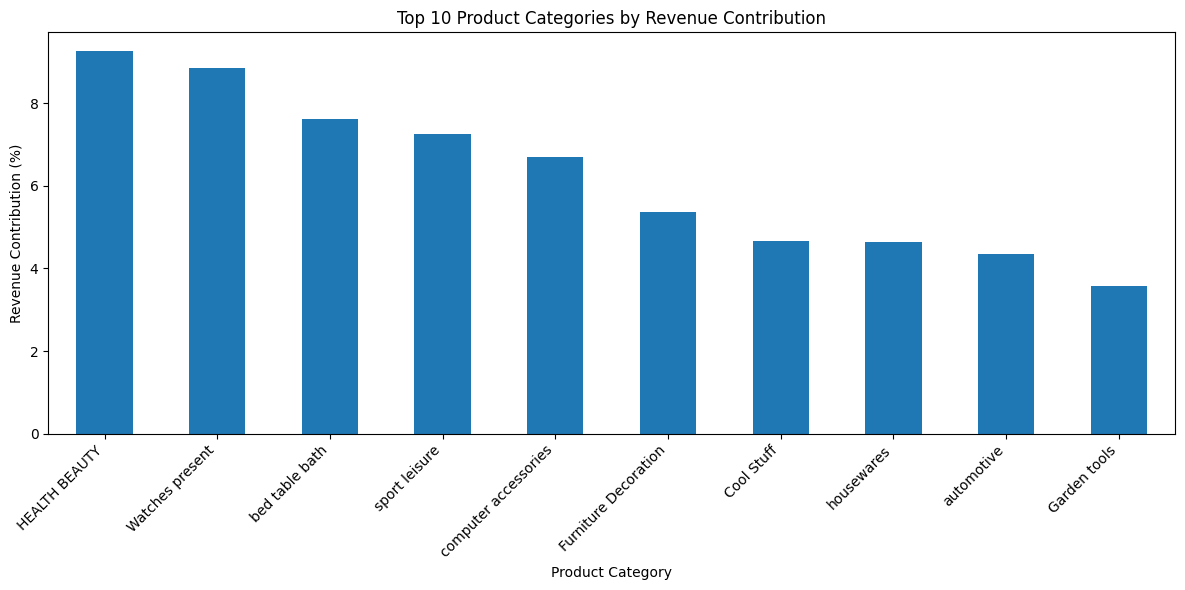

In [39]:
plt.figure(figsize=(12, 6))

category_percentage.head(10).plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue Contribution")
plt.xlabel("Product Category")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# **INTERMEDIATE 4 — Correlation between product price and purchase count**

In [45]:
product_purchase = (
    order_items
    .groupby("product_id")
    .agg(
        avg_price=("price", "mean"),
        purchase_count=("product_id", "count")
    )
    .reset_index()
)

product_purchase.head()

,product_id,avg_price,purchase_count
0,00066f42aeeb9f3007548bb9d3f33c38,101.65,1
1,00088930e925c41fd95ebfe695fd2655,129.90,1
2,0009406fd7479715e4bef61dd91f2462,229.00,1
3,000b8f95fcb9e0096488278317764d19,58.90,2
4,000d9be29b5207b54e86aa1b1ac54872,199.00,1


In [46]:
correlation = product_purchase["avg_price"].corr(
    product_purchase["purchase_count"]
)

print("Correlation between product price and purchase count:", correlation)

Correlation between product price and purchase count: -0.032139862680945167


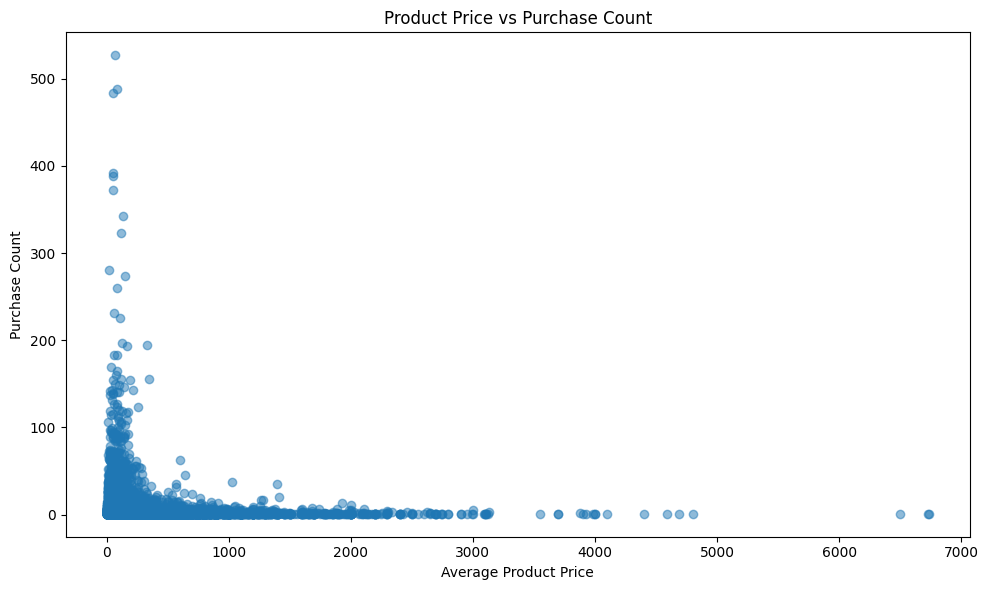

In [47]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_purchase["avg_price"],
    product_purchase["purchase_count"],
    alpha=0.5
)

plt.title("Product Price vs Purchase Count")
plt.xlabel("Average Product Price")
plt.ylabel("Purchase Count")
plt.tight_layout()
plt.show()

# **Advanced 5 — Top 3 customers by spending in each year**

In [50]:
seller_revenue = (
    order_items
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

print(seller_revenue)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
                                      ...    
34aefe746cd81b7f3b23253ea28bef39         8.00
702835e4b785b67a084280efca355756         7.60
1fa2d3def6adfa70e58c276bb64fe5bb         6.90
77128dec4bec4878c37ab7d6169d6f26         6.50
cf6f6bc4df3999b9c6440f124fb2f687         3.50
Name: price, Length: 3095, dtype: float64


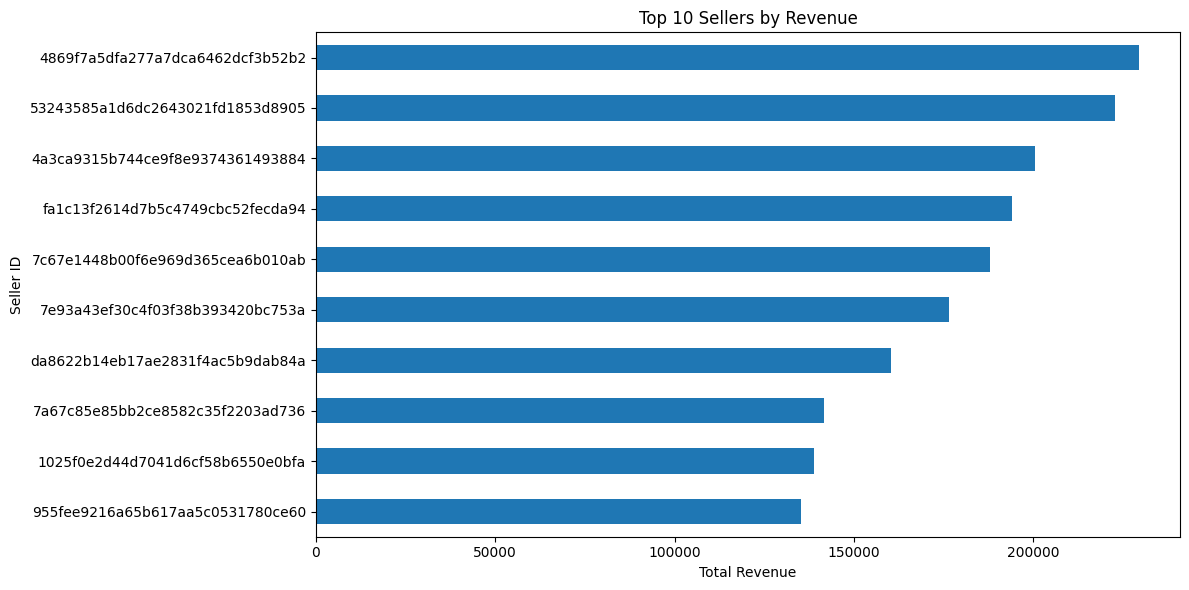

In [51]:
plt.figure(figsize=(12, 6))

seller_revenue.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.show()

# ***ADVANCED LEVEL***

# **ADVANCED 1 — Moving Average of Order Values for Each Customer**

In [81]:
# Merge orders with customers to get the unique customer ID
order_values = (
    orders
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="left"
    )
    .groupby(
        ["customer_unique_id", "order_id", "order_purchase_timestamp"]
    )["price"]
    .sum()
    .reset_index(name="order_value")
)

# Sort by customer and order date
order_values = order_values.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
)

# Calculate 3-order moving average
order_values["moving_avg"] = (
    order_values
    .groupby("customer_unique_id")["order_value"]
    .transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
)

print(order_values.head())

                 customer_unique_id                          order_id  \
0  0000366f3b9a7992bf8c76cfdf3221e2  e22acc9c116caa3f2b7121bbb380d08e   
1  0000b849f77a49e4a4ce2b2a4ca5be3f  3594e05a005ac4d06a72673270ef9ec9   
2  0000f46a3911fa3c0805444483337064  b33ec3b699337181488304f362a6b734   
3  0000f6ccb0745a6a4b88665a16c9f078  41272756ecddd9a9ed0180413cc22fb6   
4  0004aac84e0df4da2b147fca70cf8255  d957021f1127559cd947b62533f484f7   

  order_purchase_timestamp  order_value  moving_avg  
0      2018-05-10 10:56:27       129.90      129.90  
1      2018-05-07 11:11:27        18.90       18.90  
2      2017-03-10 21:05:03        69.00       69.00  
3      2017-10-12 20:29:41        25.99       25.99  
4      2017-11-14 19:45:42       180.00      180.00  


In [82]:
customer_order_counts = (
    order_values
    .groupby("customer_unique_id")
    .size()
    .sort_values(ascending=False)
)

print(customer_order_counts.head(10))

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
dc813062e0fc23409cd255f7f53c7074     6
f0e310a6839dce9de1638e0fe5ab282a     6
63cfc61cee11cbe306bff5857d00bfe4     6
de34b16117594161a6a89c50b289d35a     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
dtype: int64


In [83]:
example_customer = customer_order_counts.index[0]

customer_data = order_values[
    order_values["customer_unique_id"] == example_customer
].copy()

print("Customer:", example_customer)
print("Number of orders:", len(customer_data))
print(customer_data)

Customer: 8d50f5eadf50201ccdcedfb9e2ac8455
Number of orders: 17
                     customer_unique_id                          order_id  \
54807  8d50f5eadf50201ccdcedfb9e2ac8455  5d848f3d93a493c1c8955e018240e7ca   
54803  8d50f5eadf50201ccdcedfb9e2ac8455  369634708db140c5d2c4e365882c443a   
54806  8d50f5eadf50201ccdcedfb9e2ac8455  5837a2c844decae8a778657425f6d664   
54804  8d50f5eadf50201ccdcedfb9e2ac8455  4f62d593acae92cea3c5662c76122478   
54813  8d50f5eadf50201ccdcedfb9e2ac8455  bf92c69b7cc70f7fc2c37de43e366173   
54805  8d50f5eadf50201ccdcedfb9e2ac8455  519203404f6116d406a970763ee75799   
54817  8d50f5eadf50201ccdcedfb9e2ac8455  e3071b7624445af6e4f3a1b23718667d   
54815  8d50f5eadf50201ccdcedfb9e2ac8455  cd4b336a02aacabd0ef22f6db711f95e   
54810  8d50f5eadf50201ccdcedfb9e2ac8455  89d9b111d2b990deb5f5f9769f92800b   
54812  8d50f5eadf50201ccdcedfb9e2ac8455  b850a16d8faf65a74c51287ef34379ce   
54802  8d50f5eadf50201ccdcedfb9e2ac8455  23427a6bd9f8fd1b51f1b1e5cc186ab8   
54808  8d50f

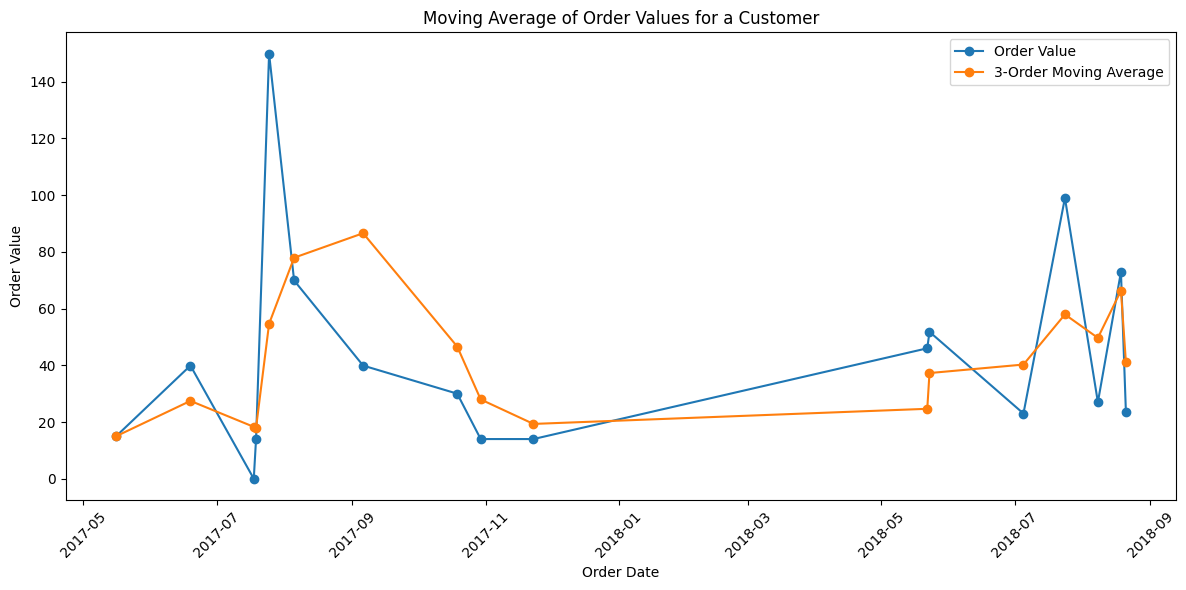

In [84]:
plt.figure(figsize=(12, 6))

plt.plot(
    customer_data["order_purchase_timestamp"],
    customer_data["order_value"],
    marker="o",
    label="Order Value"
)

plt.plot(
    customer_data["order_purchase_timestamp"],
    customer_data["moving_avg"],
    marker="o",
    label="3-Order Moving Average"
)

plt.title("Moving Average of Order Values for a Customer")
plt.xlabel("Order Date")
plt.ylabel("Order Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **ADVANCED 2 — Cumulative Sales per Month for Each Year**

In [55]:
orders["year"] = (
    orders["order_purchase_timestamp"].dt.year
)

orders["month"] = (
    orders["order_purchase_timestamp"].dt.month
)

monthly_sales = (
    orders[
        ["order_id", "year", "month"]
    ]
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="left"
    )
    .groupby(["year", "month"])["price"]
    .sum()
    .reset_index(name="monthly_sales")
)

monthly_sales = monthly_sales.sort_values(
    ["year", "month"]
)

monthly_sales["cumulative_sales"] = (
    monthly_sales
    .groupby("year")["monthly_sales"]
    .cumsum()
)

print(monthly_sales)

    year  month  monthly_sales  cumulative_sales
0   2016      9         267.36            267.36
1   2016     10       49507.66          49775.02
2   2016     12          10.90          49785.92
3   2017      1      120312.87         120312.87
4   2017      2      247303.02         367615.89
5   2017      3      374344.30         741960.19
6   2017      4      359927.23        1101887.42
7   2017      5      506071.14        1607958.56
8   2017      6      433038.60        2040997.16
9   2017      7      498031.48        2539028.64
10  2017      8      573971.68        3113000.32
11  2017      9      624401.69        3737402.01
12  2017     10      664219.43        4401621.44
13  2017     11     1010271.37        5411892.81
14  2017     12      743914.17        6155806.98
15  2018      1      950030.36         950030.36
16  2018      2      844178.71        1794209.07
17  2018      3      983213.44        2777422.51
18  2018      4      996647.75        3774070.26
19  2018      5     

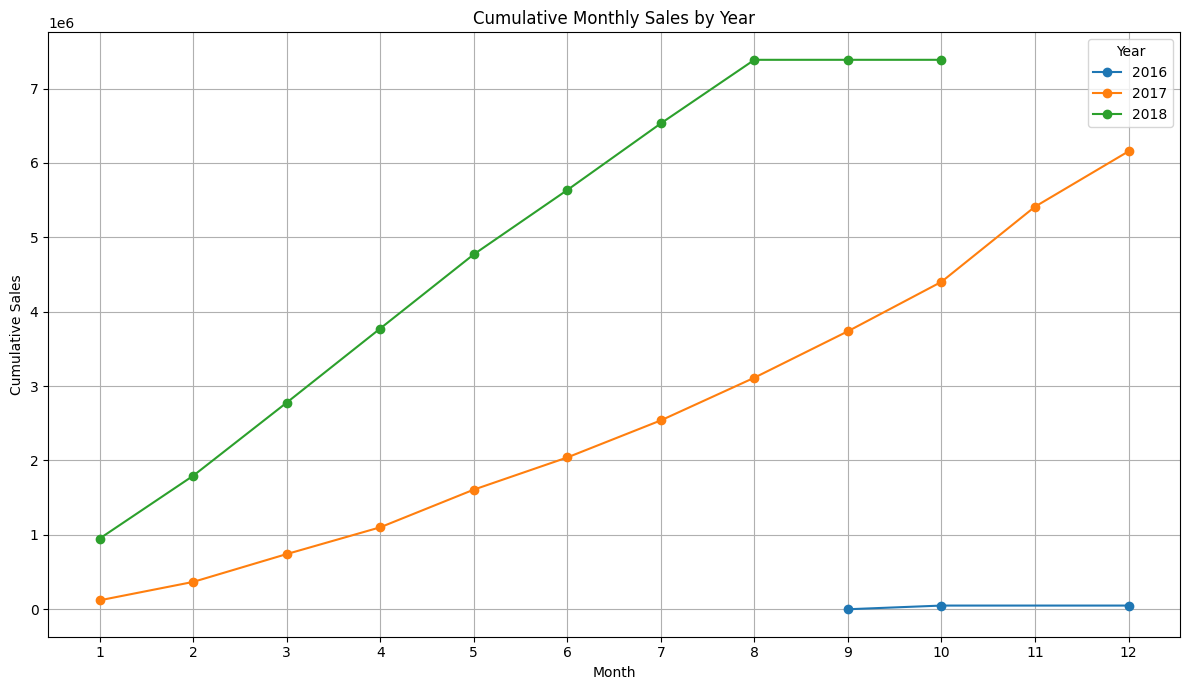

In [56]:
plt.figure(figsize=(12, 7))

for year, data in monthly_sales.groupby("year"):
    plt.plot(
        data["month"],
        data["cumulative_sales"],
        marker="o",
        label=str(year)
    )

plt.title("Cumulative Monthly Sales by Year")
plt.xlabel("Month")
plt.ylabel("Cumulative Sales")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.grid()
plt.tight_layout()
plt.show()

# **ADVANCED 3 — Year-over-Year Growth Rate of Total Sales**

In [70]:

yearly_sales = (
    orders[["order_id", "year"]]
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="left"
    )
    .groupby("year")["price"]
    .sum()
    .reset_index(name="total_sales")
)

# Make sure years are integers
yearly_sales["year"] = yearly_sales["year"].astype(int)

# Calculate YoY growth
yearly_sales["yoy_growth"] = (
    yearly_sales["total_sales"]
    .pct_change() * 100
)

print(yearly_sales)

   year  total_sales    yoy_growth
0  2016     49785.92           NaN
1  2017   6155806.98  12264.554035
2  2018   7386050.80     19.985094


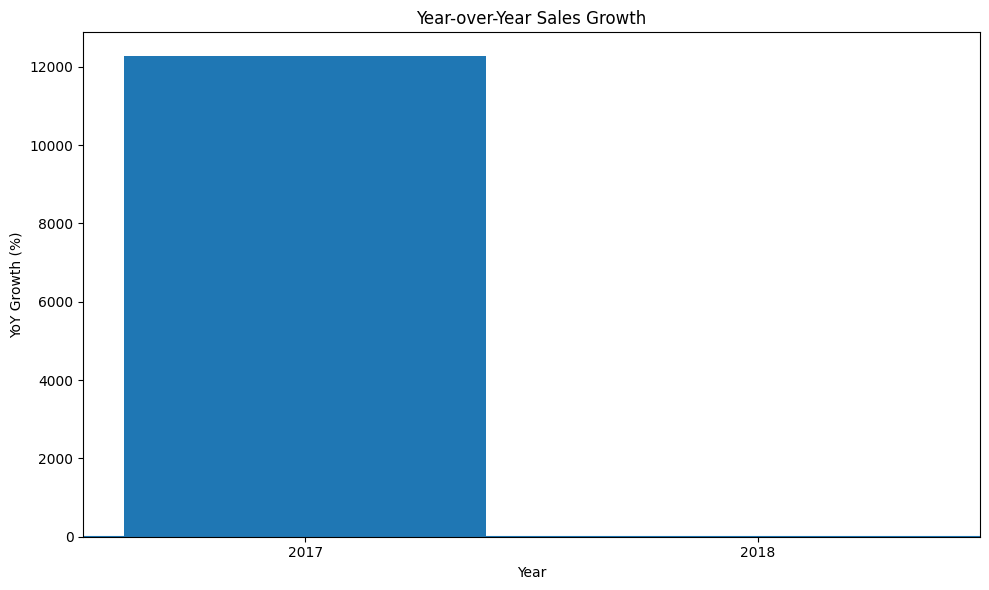

In [71]:
yoy_data = yearly_sales.dropna(subset=["yoy_growth"]).copy()

plt.figure(figsize=(10, 6))

plt.bar(
    yoy_data["year"].astype(str),
    yoy_data["yoy_growth"]
)

plt.title("Year-over-Year Sales Growth")
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")

plt.axhline(0)

plt.tight_layout()
plt.show()

# **ADVANCED 4 — Customer Retention Rate Within 6 Months**

In [60]:
customer_orders = (
    orders[
        orders["order_status"] == "delivered"
    ][
        ["order_id", "customer_id", "order_purchase_timestamp"]
    ]
    .merge(
        customers[
            ["customer_id", "customer_unique_id"]
        ],
        on="customer_id",
        how="left"
    )
)

In [61]:
first_purchase = (
    customer_orders
    .groupby("customer_unique_id")[
        "order_purchase_timestamp"
    ]
    .min()
    .reset_index(name="first_purchase")
)

In [62]:
max_purchase_date = (
    customer_orders["order_purchase_timestamp"].max()
)

eligible_customers = first_purchase[
    first_purchase["first_purchase"]
    <= max_purchase_date - pd.DateOffset(months=6)
].copy()

In [63]:
retained = customer_orders.merge(
    eligible_customers,
    on="customer_unique_id",
    how="inner"
)

retained = retained[
    (retained["order_purchase_timestamp"] > retained["first_purchase"]) &
    (
        retained["order_purchase_timestamp"]
        <= retained["first_purchase"]
        + pd.DateOffset(months=6)
    )
]

retained_customers = (
    retained["customer_unique_id"]
    .nunique()
)

total_customers = (
    eligible_customers["customer_unique_id"]
    .nunique()
)

retention_rate = (
    retained_customers /
    total_customers
) * 100

print("Eligible customers:", total_customers)
print("Retained customers:", retained_customers)
print(f"Retention rate: {retention_rate:.2f}%")

Eligible customers: 55364
Retained customers: 1560
Retention rate: 2.82%


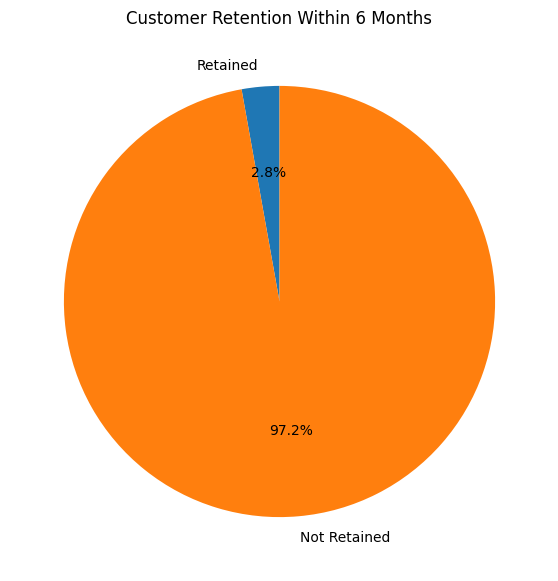

In [64]:
retention_data = pd.Series({
    "Retained": retained_customers,
    "Not Retained": total_customers - retained_customers
})

plt.figure(figsize=(7, 7))

retention_data.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Retention Within 6 Months")
plt.ylabel("")
plt.show()

# **ADVANCED 5 — Top 3 Customers Who Spent the Most Money in Each Year**

In [65]:
customer_year_sales = (
    orders[
        ["order_id", "customer_id", "order_purchase_timestamp"]
    ]
    .merge(
        customers[
            ["customer_id", "customer_unique_id"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        order_items[
            ["order_id", "price"]
        ],
        on="order_id",
        how="left"
    )
)

customer_year_sales["year"] = (
    customer_year_sales[
        "order_purchase_timestamp"
    ].dt.year
)

customer_year_sales = (
    customer_year_sales
    .groupby(
        ["year", "customer_unique_id"]
    )["price"]
    .sum()
    .reset_index(name="total_spent")
)

In [66]:
top_3_customers = (
    customer_year_sales
    .sort_values(
        ["year", "total_spent"],
        ascending=[True, False]
    )
    .groupby("year")
    .head(3)
)

print(top_3_customers)

       year                customer_unique_id  total_spent
320    2016  fdaa290acb9eeacb66fa7f979baa6803      1399.00
145    2016  753bc5d6efa9e49a03e34cf521a9e124      1299.99
235    2016  b92a2e5e8a6eabcc80882c7d68b2c70b      1199.00
2076   2017  0a0a92112bd4c708ca5fde585afaa872     13440.00
37663  2017  da122df9eeddfedc1dc1f5349a1a690c      7388.00
38034  2017  dc4802a71eae9be1dd28f5d788ceb526      6735.00
68457  2018  763c8b1c9c68a0229c42c9fc6f662b93      7160.00
58411  2018  459bef486812aa25204be022145caa62      6729.00
63274  2018  5d0a2980b292d049061542014e8960bf      4599.90


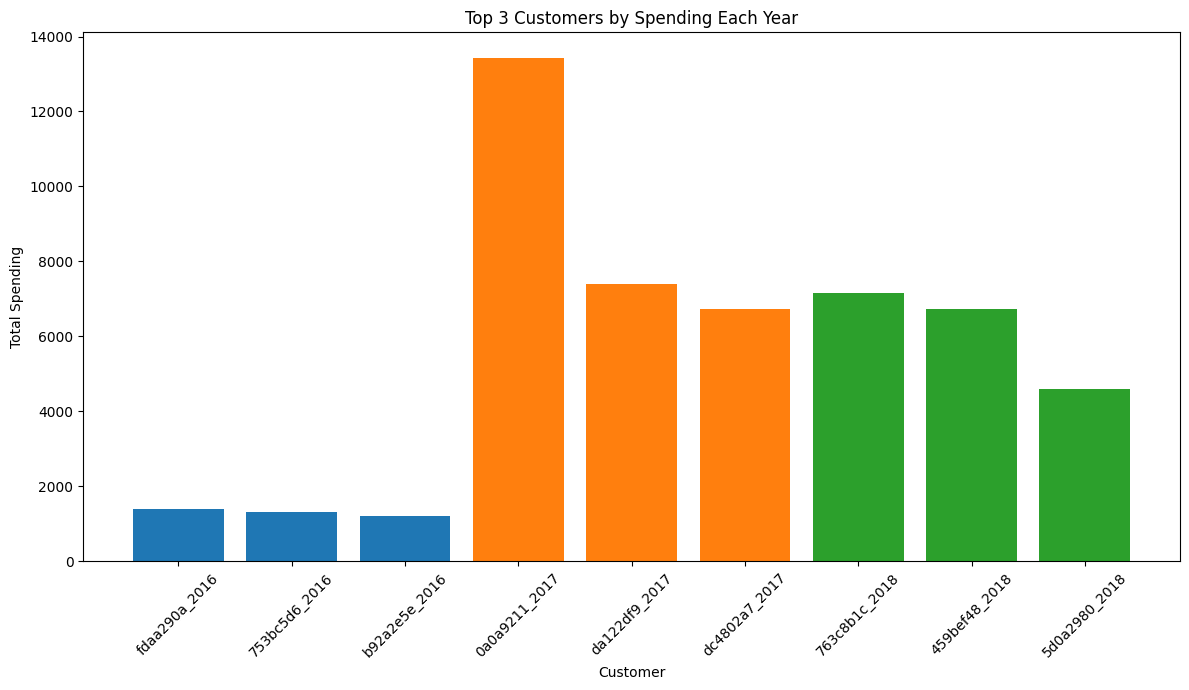

In [67]:
plt.figure(figsize=(12, 7))

plot_data = top_3_customers.copy()

plot_data["customer_label"] = (
    plot_data["customer_unique_id"]
    .str[:8]
)

for year, data in plot_data.groupby("year"):
    plt.bar(
        data["customer_label"] + "_" + data["year"].astype(str),
        data["total_spent"],
        label=str(year)
    )

plt.title("Top 3 Customers by Spending Each Year")
plt.xlabel("Customer")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()